In [15]:
India_mask = False
train_type = 'pre_final'


In [16]:
import os
import numpy as np
import torch
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MaxNLocator
from tqdm import tqdm
import xarray as xr
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import LinearLR, SequentialLR
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.distributed as dist
from torch.utils.data.distributed import DistributedSampler
from tqdm import tqdm
import numpy as np
import argparse
from sfno import SphericalFourierNeuralOperatorNet as SFNO

import matplotlib.pyplot as plt
torch.autograd.set_detect_anomaly(True)
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import imageio.v2 as imageio
import io
from scipy import stats

from latweightedloss import LatWeightedLoss
import threading
import queue
import numpy as np
import xarray as xr
import torch
import time
import dask

dask.config.set(scheduler='synchronous')
plt.style.use('seaborn-v0_8-darkgrid')

# ─────────────────────────────────────────────
# ERA5 PREFETCHER
# ─────────────────────────────────────────────

class ERA5Prefetcher:
    def __init__(self, ds, batch_size, queue_size=4, sequence_length=14, device="cpu",
                 check_nans=False, normalize=True,
                 means='means_era5_dataset.npy', stds='std_era5_dataset.npy'):
        self.ds = ds
        self.B = batch_size
        self.time_max = self.ds.time.size - sequence_length
        self.queue = queue.Queue(maxsize=queue_size)
        self.device = device
        self.seq_len = sequence_length
        self.stop_event = threading.Event()
        self.thread = threading.Thread(target=self._worker, daemon=True)
        self.valid_indices = self.get_valid_indices()
        self.check_nans = check_nans
        self.normalize = normalize
        if self.normalize:
            self.means = np.load(means)
            self.stds = np.load(stds)

    def get_valid_indices(self):
        time_max = self.time_max
        nan_times = np.load('nan_times.npy')
        offsets = np.arange(-self.seq_len - 1, self.seq_len + 1)
        masks = np.unique((nan_times[:, None] + offsets[None, :]).flatten())
        arr = np.arange(time_max)
        masks = masks[(masks <= time_max)]
        arr[masks] = -1
        arr = arr[(arr >= 0) & (arr < time_max)]
        return np.unique(arr)

    def start(self):
        self.thread.start()

    def stop(self):
        self.stop_event.set()
        while not self.queue.empty():
            try:
                self.queue.get_nowait()
            except queue.Empty:
                break
        self.thread.join()

    def _worker(self):
        worker_id = threading.get_ident()
        print(f"[Worker {worker_id}] started")
        while not self.stop_event.is_set():
            if self.queue.full():
                time.sleep(0.01)
                continue
            loc = np.random.choice(self.valid_indices, size=self.B)
            print(loc, end='')
            time_idx = loc[:, None] + np.arange(self.seq_len)[None, :]
            try:
                batch_view = self.ds['era5_features'].isel(
                    time=xr.DataArray(time_idx, dims=("batch", "step"))
                ).transpose("batch", "channel", "step", "latitude", "longitude")

                if self.normalize:
                    numpy_batch = batch_view.values
                    means = np.expand_dims(self.means, axis=(2, 3, 4))
                    stds = np.expand_dims(self.stds, axis=(2, 3, 4))
                    numpy_batch = (numpy_batch - means) / stds
                else:
                    numpy_batch = batch_view.values

                if self.check_nans:
                    if np.isnan(numpy_batch).any():
                        print('!!!! Error nan found.')
                        np.save('time_ids_for_nans.npy', time_idx)

                tensor = torch.from_numpy(numpy_batch).contiguous().float()
                if torch.cuda.is_available():
                    tensor = tensor.pin_memory()
                self.queue.put(tensor)

            except Exception as e:
                print(f"Worker Error: {e}")
                self.stop_event.set()

    def get(self):
        return self.queue.get(timeout=600)


# ─────────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────────

ROLLOUT_STEPS = 15
BATCH_SIZE    = 1
NUM_SAMPLES   = 100
DEVICE        = 'cuda:0' if torch.cuda.is_available() else 'cpu'

CHANNEL_NAMES = [
    'u_wind_250', 'u_wind_500', 'u_wind_850',
    'v_wind_250', 'v_wind_500', 'v_wind_850',
    'temp_250',   'temp_500',   'temp_850',
    'z_250',      'z_500',      'z_850',
    'w_250',      'w_500',      'w_850',
    'q_250',      'q_500',      'q_850',
    'u10m',       'v10m',       't2m',
    'mslp',       'tcwv',
]
CHANNEL_LABELS = [
    'U-wind 250hPa',   'U-wind 500hPa',   'U-wind 850hPa',
    'V-wind 250hPa',   'V-wind 500hPa',   'V-wind 850hPa',
    'Temp 250hPa',     'Temp 500hPa',     'Temp 850hPa',
    'Geopot 250hPa',   'Geopot 500hPa',   'Geopot 850hPa',
    'Vert-vel 250hPa', 'Vert-vel 500hPa', 'Vert-vel 850hPa',
    'Spec-hum 250hPa', 'Spec-hum 500hPa', 'Spec-hum 850hPa',
    'U-wind 10m',      'V-wind 10m',      'Temp 2m',
    'MSLP',            'TCWV',
]
N_CHANNELS = len(CHANNEL_NAMES)

# Output directories
OUT_BASE  = f'eval_results_{train_type}train'
DIR_RMSE  = os.path.join(OUT_BASE, 'rmse')
DIR_ACC   = os.path.join(OUT_BASE, 'acc')
DIR_POWER = os.path.join(OUT_BASE, 'power')

for d in [DIR_RMSE, DIR_ACC, DIR_POWER]:
    os.makedirs(d, exist_ok=True)


# ─────────────────────────────────────────────
# HELPERS
# ─────────────────────────────────────────────

def lat_weights(num_lat: int, device='cpu') -> torch.Tensor:
    lat_t  = torch.arange(num_lat, dtype=torch.float32, device=device)
    interm = 90.0 - lat_t * 180.0 / float(num_lat - 1)
    cos    = torch.cos(torch.deg2rad(interm))
    w      = num_lat * cos / cos.sum()
    return w.reshape(1, -1, 1)


def weighted_rmse(pred, truth, india_mask=False,
                  hslice=slice(64, 85), wslice=slice(40, 65)):
    w = lat_weights(pred.shape[1], device=pred.device)
    if india_mask:
        pred  = pred[:,  hslice, wslice]
        truth = truth[:, hslice, wslice]
        w     = w[:, hslice, :]
    return torch.sqrt(torch.mean(w * (pred - truth) ** 2, dim=(-1, -2)))


def weighted_acc(pred, truth, clim_mean, india_mask=False,
                 hslice=slice(64, 85), wslice=slice(40, 65)):
    p = (pred  - clim_mean)
    t = (truth - clim_mean)
    w = lat_weights(p.shape[1], device=pred.device)
    if india_mask:
        p = p[:,  hslice, wslice]
        t = t[:, hslice, wslice]
        w = w[:, hslice, :]
    num   = torch.sum(w * p * t,           dim=(-1, -2))
    denom = torch.sqrt(torch.sum(w * p * p, dim=(-1, -2)) *
                       torch.sum(w * t * t, dim=(-1, -2)))
    return num / (denom + 1e-12)


# ─────────────────────────────────────────────
# POWER SPECTRUM
# ─────────────────────────────────────────────

def spherical_power_spectrum_fft(field: np.ndarray):
    """
    Approximate spherical power spectrum via 2-D FFT with cosine-latitude
    weighting.  Bins into annuli of radius |k|.

    Parameters
    ----------
    field : ndarray (lat, lon)

    Returns
    -------
    wavenumbers : ndarray
    power       : ndarray
    """
    nlat, nlon = field.shape
    lats    = np.linspace(90, -90, nlat, endpoint=False) * np.pi / 180.0
    cos_lat = np.cos(lats)[:, None]
    weighted = field * np.sqrt(cos_lat)
    F  = np.fft.fft2(weighted)
    amplitude2 = np.abs(F) ** 2 / (nlat * nlon) ** 2
    kx = np.fft.fftfreq(nlon) * nlon
    ky = np.fft.fftfreq(nlat) * nlat
    KX, KY = np.meshgrid(kx, ky)
    K = np.sqrt(KX ** 2 + KY ** 2).ravel()
    A = amplitude2.ravel()
    kmax  = int(min(nlon, nlat) // 2)
    kbins = np.arange(0.5, kmax + 1.5, 1.0)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    power, _, _ = stats.binned_statistic(K, A, statistic="sum", bins=kbins)
    return kvals, power


# ─────────────────────────────────────────────
# ROLLOUT EVALUATION
# ─────────────────────────────────────────────

def evaluate_rollout(model, prefetcher, time_means, time_stds,
                     num_samples=NUM_SAMPLES, rollout_steps=ROLLOUT_STEPS,
                     device=DEVICE, india_mask=False):
    """
    Returns
    -------
    rmse_matrix  : (num_samples, rollout_steps, C)
    acc_matrix   : (num_samples, rollout_steps, C)
    pred_samples : list of (C, lat, lon) tensors — final-step predictions
    gt_samples   : list of (C, lat, lon) tensors — final-step ground truth
    """
    model.eval()
    clim_mean = torch.from_numpy(time_means)[0,:,:,:].to(device)

    rmse_all, acc_all = [], []
    pred_samples, gt_samples = [], []

    for sample_i in tqdm(range(num_samples), desc="Evaluating rollout"):
        batch = prefetcher.get().to(device)   # (1, C, T, lat, lon)

        sample_rmse, sample_acc = [], []
        x = batch[:, :, 0, :, :]              # (1, C, lat, lon)

        for step in range(rollout_steps):
            with torch.no_grad():
                pred_norm = model(x)

            gt_norm = batch[:, :, step + 1, :, :]

            rmse_step = weighted_rmse(
                pred_norm[0], gt_norm[0], india_mask=india_mask
            ).detach().cpu().numpy()

            acc_step = weighted_acc(
                pred_norm[0], gt_norm[0], clim_mean, india_mask=india_mask
            ).detach().cpu().numpy()

            sample_rmse.append(rmse_step)
            sample_acc.append(acc_step)
            x = pred_norm.detach()

        rmse_all.append(sample_rmse)
        acc_all.append(sample_acc)

        # store final-step pred & gt for power-spectrum computation
        pred_samples.append(pred_norm[0].detach().cpu())
        gt_samples.append(gt_norm[0].detach().cpu())

    return (np.array(rmse_all), np.array(acc_all),
            pred_samples, gt_samples)


# ─────────────────────────────────────────────
# STYLE HELPERS
# ─────────────────────────────────────────────

BG_DARK    = '#0d1117'
AX_DARK    = '#161b22'
ACCENT     = '#00d4aa'
GRID_COL   = '#1e2a35'
TEXT_COL   = '#c9d1d9'
TITLE_COL  = '#ffffff'
BAND_COL   = '#00d4aa33'
BAND_COL   = '#cfe2f3'

# def _style_ax(ax):
    # ax.set_facecolor(AX_DARK)
    # ax.tick_params( labelsize=7.5)
    # for sp in ax.spines.values():
        # sp.set_edgecolor(GRID_COL)
    # ax.grid(color=GRID_COL, linewidth=0.6)


# ─────────────────────────────────────────────
# RMSE / ACC PLOTTING
# ─────────────────────────────────────────────

def _plot_single_channel(steps, mean_c, p25_c, p75_c, label, metric_name):
    """Return a Figure with a single channel metric curve."""
    fig, ax = plt.subplots(figsize=(5, 3.5) )  #facecolor=BG_DARK
    # _style_ax(ax)
    ax.plot(steps, mean_c,  linewidth=2.2, solid_capstyle='round')
    ax.fill_between(steps, p25_c, p75_c,  linewidth=0,color=BAND_COL,)
    ax.set_title(label,  fontsize=11,  pad=6)
    ax.set_xlabel('Rollout step',  fontsize=9)
    ax.set_ylabel(metric_name, fontsize=9)
    if metric_name == 'ACC':
        ax.set_ylim(-1, 1)
    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
    ax.ticklabel_format(style='plain', axis='y')
    plt.tight_layout()
    return fig


def plot_metric_grid(matrix, metric_name, channel_labels=CHANNEL_LABELS,
                     rollout_steps=ROLLOUT_STEPS, save_path=None, India_mask=False):
    """
    Grid of all channels.
    matrix : (num_samples, rollout_steps, C)
    """
    mean  = matrix.mean(axis=0)
    p25   = np.percentile(matrix, 25, axis=0)
    p75   = np.percentile(matrix, 75, axis=0)
    steps = np.arange(1, rollout_steps + 1)
    C     = mean.shape[1]
    NCOLS = 4
    NROWS = (C + NCOLS - 1) // NCOLS

    fig = plt.figure(figsize=(NCOLS * 4.5, NROWS * 3.2)) #facecolor=BG_DARK
    gs  = gridspec.GridSpec(NROWS, NCOLS, figure=fig, hspace=0.55, wspace=0.35)

    for c in range(C):
        row, col = divmod(c, NCOLS)
        ax = fig.add_subplot(gs[row, col])
        # _style_ax(ax)
        ax.plot(steps, mean[:, c], 
                linewidth=2.0, solid_capstyle='round')
        ax.fill_between(steps, p25[:, c], p75[:, c],
                        color=BAND_COL,linewidth=0)
        ax.set_title(channel_labels[c], 
                     fontsize=9.5,  pad=6)
        ax.set_xlabel('Rollout step',  fontsize=7.5)
        ax.set_ylabel(metric_name,    fontsize=7.5)
        if metric_name == 'ACC':
            ax.set_ylim(-1, 1)
        ax.ticklabel_format(style='plain', axis='y')
        ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

    for c in range(C, NROWS * NCOLS):
        row, col = divmod(c, NCOLS)
        fig.add_subplot(gs[row, col]).set_visible(False)

    sup = ('Weighted RMSE per Channel — AR Rollout'
           if metric_name == 'RMSE'
           else 'Weighted ACC per Channel — AR Rollout')
    fig.suptitle(sup,  fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f'Saved → {save_path}')
    plt.close(fig)


def save_metric_per_variable(matrix, metric_name, out_dir,
                              channel_names=CHANNEL_NAMES,
                              channel_labels=CHANNEL_LABELS,
                              rollout_steps=ROLLOUT_STEPS,
                              India_mask=False):
    """
    Save one plot per variable inside `out_dir`.
    """
    mean  = matrix.mean(axis=0)
    p25   = np.percentile(matrix, 25, axis=0)
    p75   = np.percentile(matrix, 75, axis=0)
    steps = np.arange(1, rollout_steps + 1)

    for c, (cname, clabel) in enumerate(zip(channel_names, channel_labels)):
        fig = _plot_single_channel(
            steps, mean[:, c], p25[:, c], p75[:, c], clabel, metric_name
        )
        fname = os.path.join(out_dir, f'{metric_name.lower()}_{cname}_India_{India_mask}.png')
        fig.savefig(fname, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        plt.close(fig)
        print(f'  Saved → {fname}')


# ─────────────────────────────────────────────
# POWER SPECTRUM PLOTTING
# ─────────────────────────────────────────────

def _plot_power_single(wn_truth, P_truth, wn_pred, P_pred,
                       channel_label, channel_name):
    """Return a Figure with the power spectrum for one variable."""
    fig, ax = plt.subplots(figsize=(7, 4),)
    # _style_ax(ax)
    ax.loglog(wn_truth[1:], P_truth[1:], 
              lw=2.2, ls='-',  label='ERA5 (truth)')
    ax.loglog(wn_pred[1:],  P_pred[1:],  
              lw=1.8, ls='--', label='Model')

    for n_label, scale_km in [(10, '4000 km'), (40, '1000 km'), (200, '200 km')]:
        ax.axvline(n_label, color='#555', lw=0.8, ls=':')

    ax.set_xlabel('Total Spherical Wavenumber  n',  fontsize=10)
    ax.set_ylabel('Power Spectral Density  P(n)',  fontsize=10)
    ax.set_title(f'Power Spectrum  –  {channel_label}',
                  fontsize=11, pad=8)
    ax.legend(facecolor='#1a1f2b', edgecolor='#444',
              fontsize=9)
    # ax.tick_params(colors=TEXT_COL)
    plt.tight_layout()
    return fig


def plot_power_spectra_grid(wn_truth_all, P_truth_all,
                            wn_pred_all, P_pred_all,
                            channel_labels=CHANNEL_LABELS,
                            channel_names=CHANNEL_NAMES,
                            save_path=None):
    """
    Grid of power spectra for all channels.
    *_all : list of length C, each element is a 1-D array.
    """
    C     = len(channel_labels)
    NCOLS = 4
    NROWS = (C + NCOLS - 1) // NCOLS

    fig = plt.figure(figsize=(NCOLS * 5, NROWS * 3.5)) # facecolor=BG_DARK
    gs  = gridspec.GridSpec(NROWS, NCOLS, figure=fig, hspace=0.6, wspace=0.4)

    for c in range(C):
        row, col = divmod(c, NCOLS)
        ax = fig.add_subplot(gs[row, col])
        # _style_ax(ax)

        wt, Pt = wn_truth_all[c], P_truth_all[c]
        wp, Pp = wn_pred_all[c],  P_pred_all[c]

        ax.loglog(wt[1:], Pt[1:],  lw=1.8, ls='-',  label='ERA5')
        ax.loglog(wp[1:], Pp[1:], color='#4fc3f7', lw=1.5, ls='--', label='Model')
        ax.set_title(channel_labels[c],
                     fontsize=9,  pad=5)
        ax.set_xlabel('Wavenumber',  fontsize=7)
        ax.set_ylabel('PSD',  fontsize=7)
        ax.legend(facecolor='#1a1f2b', edgecolor='#444',
                   fontsize=7)

    for c in range(C, NROWS * NCOLS):
        row, col = divmod(c, NCOLS)
        fig.add_subplot(gs[row, col]).set_visible(False)

    fig.suptitle('Power Spectrum per Channel', color=TITLE_COL,
                 fontsize=15, y=1.01)
    plt.tight_layout()

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        print(f'Saved → {save_path}')
    plt.close(fig)


def save_power_spectra_per_variable(wn_truth_all, P_truth_all,
                                    wn_pred_all, P_pred_all,
                                    out_dir,
                                    channel_labels=CHANNEL_LABELS,
                                    channel_names=CHANNEL_NAMES):
    """Save one power-spectrum plot per variable into out_dir."""
    for c, (cname, clabel) in enumerate(zip(channel_names, channel_labels)):
        fig = _plot_power_single(
            wn_truth_all[c], P_truth_all[c],
            wn_pred_all[c],  P_pred_all[c],
            clabel, cname
        )
        fname = os.path.join(out_dir, f'power_{cname}.png')
        fig.savefig(fname, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        plt.close(fig)
        print(f'  Saved → {fname}')


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

if __name__ == '__main__':
    import sys
    sys.path.insert(0, '.')

    time_means = np.load('means_era5_dataset.npy')   # (C,)
    time_stds  = np.load('std_era5_dataset.npy')     # (C,)
    clim_means = np.load('clim.npy')
    ds = xr.open_zarr('/storage/vishnu/era5_stacked.zarr/', chunks={})
    ds = ds.sel(time=slice('2019-01-01', '2019-12-31'))
   
    prefetcher = ERA5Prefetcher(
        ds,
        batch_size=BATCH_SIZE,
        queue_size=4,
        sequence_length=ROLLOUT_STEPS + 1,
        device=DEVICE,
        check_nans=False,
        normalize=True,
    )
    prefetcher.start()

    nlat, nlon = ds.latitude.size, ds.longitude.size
    model = SFNO(
        operator_type='driscoll-healy',
        img_size=(nlat, nlon),
        num_layers=8,
        scale_factor=2,
        embed_dim=384,
        pos_embed='latlon',
        use_mlp=True,
        activation_function='gelu',
        normalization_layer='layer_norm',
        hard_thresholding_fraction=1.0,
        in_chans=N_CHANNELS,
        out_chans=N_CHANNELS,
    ).to(DEVICE)

    # ckpt = 'sfno_phase4SPHERE_layernorm_10_final.pth'
    ckpt = 'sfno_phase1SPHERE_layernorm_10000.pth'
    if os.path.exists(ckpt):
        model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
        print('Loaded checkpoint.')

    
    # ── Rollout evaluation ─────────────────────────────────────────
    rmse_matrix, acc_matrix, pred_samples, gt_samples = evaluate_rollout(
        model, prefetcher, clim_means, time_stds,
        num_samples=NUM_SAMPLES,
        rollout_steps=ROLLOUT_STEPS,
        device=DEVICE,
        india_mask=India_mask,
    )
    prefetcher.stop()

    np.save(f'rollout_rmse_India_{India_mask}_{train_type}train.npy', rmse_matrix)
    np.save(f'rollout_acc_India_{India_mask}_{train_type}train.npy',  acc_matrix)
    print(f'Saved rollout_rmse_India_{India_mask}_{train_type}train.npy and rollout_acc_India_{India_mask}_{train_type}train.npy')

    # ── RMSE: grid + per-variable ──────────────────────────────────
    print('\n── RMSE plots ──')
    plot_metric_grid(rmse_matrix, 'RMSE',
                     save_path=os.path.join(DIR_RMSE, f'rmse_all_channels_India_{India_mask}_{train_type}train.png'))
    save_metric_per_variable(rmse_matrix, 'RMSE', DIR_RMSE, India_mask = India_mask)

    # ── ACC: grid + per-variable ───────────────────────────────────
    print('\n── ACC plots ──')
    plot_metric_grid(acc_matrix, 'ACC',
                     save_path=os.path.join(DIR_ACC, f'acc_all_channels_India_{India_mask}_{train_type}train.png'))
    save_metric_per_variable(acc_matrix, 'ACC', DIR_ACC, India_mask = India_mask)

    # ── Power spectra: compute, grid + per-variable ────────────────
    print('\n── Power spectrum ──')

    # Average predictions and ground truth over samples
    # pred_samples / gt_samples: list of NUM_SAMPLES tensors, each (C, lat, lon)
    pred_mean = torch.stack(pred_samples).mean(dim=0).numpy()   # (C, lat, lon)
    gt_mean   = torch.stack(gt_samples).mean(dim=0).numpy()     # (C, lat, lon)

    # Un-normalise for physically meaningful spectra
    pred_phys = pred_mean 
    gt_phys   = gt_mean   

    wn_truth_all, P_truth_all = [], []
    wn_pred_all,  P_pred_all  = [], []

    # print('Computing power spectra per channel …')
    # for c in tqdm(range(N_CHANNELS)):
    #     wt, Pt = spherical_power_spectrum_fft(gt_phys[c])
    #     wp, Pp = spherical_power_spectrum_fft(pred_phys[c])
    #     wn_truth_all.append(wt);  P_truth_all.append(Pt)
    #     wn_pred_all.append(wp);   P_pred_all.append(Pp)

    # # Grid
    # plot_power_spectra_grid(
    #     wn_truth_all, P_truth_all,
    #     wn_pred_all,  P_pred_all,
    #     save_path=os.path.join(DIR_POWER, 'power_all_channels.png'),
    # )

    # # Per-variable
    # save_power_spectra_per_variable(
    #     wn_truth_all, P_truth_all,
    #     wn_pred_all,  P_pred_all,
    #     out_dir=DIR_POWER,
    # )

    print('\nAll done!  Output structure:')
    print(f'  {DIR_RMSE}/  — rmse_all_channels.png + rmse_<var>.png × {N_CHANNELS}')
    print(f'  {DIR_ACC}/   — acc_all_channels.png  + acc_<var>.png  × {N_CHANNELS}')
    print(f'  {DIR_POWER}/ — power_all_channels.png + power_<var>.png × {N_CHANNELS}')

[Worker 139949462501120] started
[271][1110][797]Loaded checkpoint.


Evaluating rollout:   0%|                                                                                                                                              | 0/100 [00:00<?, ?it/s]

[460]

Evaluating rollout:   2%|██▋                                                                                                                                   | 2/100 [00:00<00:39,  2.51it/s]

[729]

...

[1035]

Evaluating rollout: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [00:50<00:00,  1.98it/s]


Saved rollout_rmse_India_False_pre_finaltrain.npy and rollout_acc_India_False_pre_finaltrain.npy

── RMSE plots ──


/tmp/ipykernel_1341589/2201590147.py:384: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved → eval_results_pre_finaltrain/rmse/rmse_all_channels_India_False_pre_finaltrain.png
  Saved → eval_results_pre_finaltrain/rmse/rmse_u_wind_250_India_False.png
  Saved → eval_results_pre_finaltrain/rmse/rmse_u_wind_500_India_False.png
  Saved → eval_results_pre_finaltrain/rmse/rmse_u_wind_850_India_False.png
  Saved → eval_results_pre_finaltrain/rmse/rmse_v_wind_250_India_False.png
  Saved → eval_results_pre_finaltrain/rmse/rmse_v_wind_500_India_False.png
  Saved → eval_results_pre_finaltrain/rmse/rmse_v_wind_850_India_False.png
  Saved → eval_results_pre_finaltrain/rmse/rmse_temp_250_India_False.png
  Saved → eval_results_pre_finaltrain/rmse/rmse_temp_500_India_False.png
  Saved → eval_results_pre_finaltrain/rmse/rmse_temp_850_India_False.png
  Saved → eval_results_pre_finaltrain/rmse/rmse_z_250_India_False.png
  Saved → eval_results_pre_finaltrain/rmse/rmse_z_500_India_False.png
  Saved → eval_results_pre_finaltrain/rmse/rmse_z_850_India_False.png
  Saved → eval_results_pre_fina

Loaded saved matrices.
Saved → eval_results_pre_finaltrain_all_in_one/rmse/rmse_all_single_India_False.png
Saved → eval_results_pre_finaltrain_all_in_one/acc/acc_all_single_India_False.png


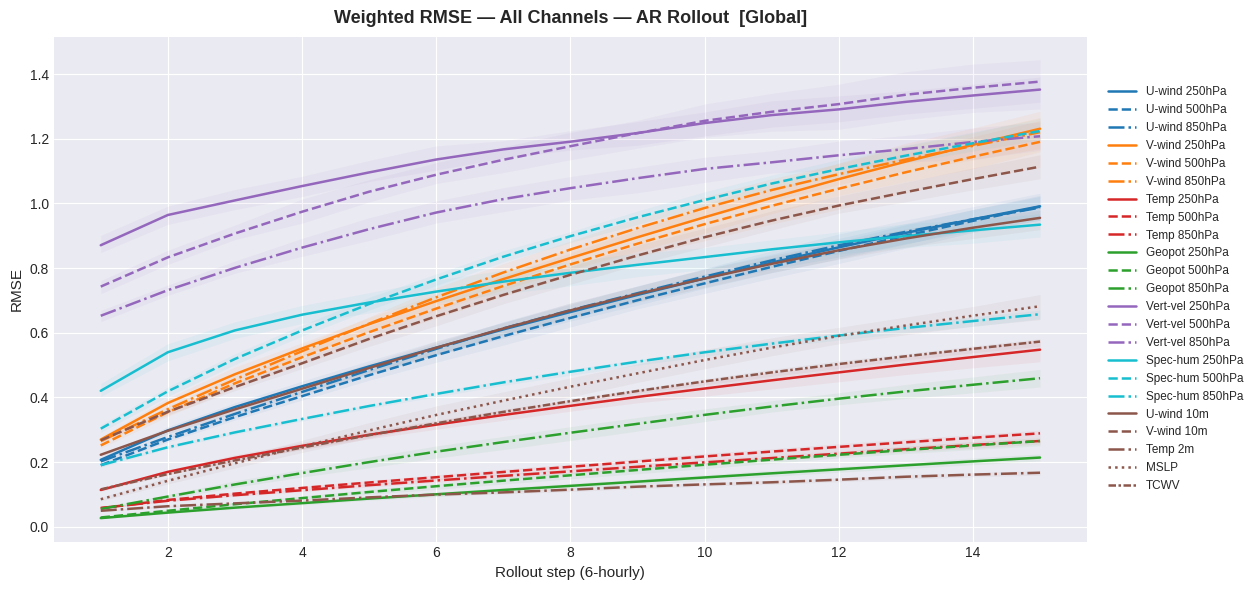

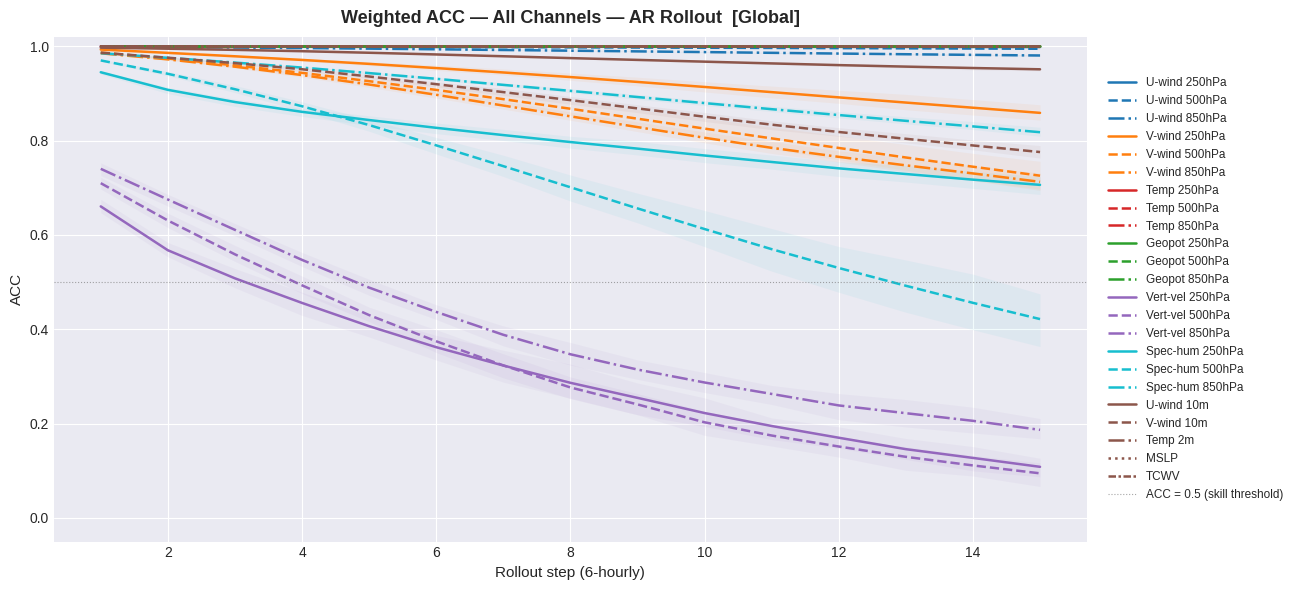

Done.


In [17]:
## all var in one
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator

plt.style.use('seaborn-v0_8-darkgrid')

BAND_COL = '#cfe2f3'

CHANNEL_NAMES = [
    'u_wind_250', 'u_wind_500', 'u_wind_850',
    'v_wind_250', 'v_wind_500', 'v_wind_850',
    'temp_250',   'temp_500',   'temp_850',
    'z_250',      'z_500',      'z_850',
    'w_250',      'w_500',      'w_850',
    'q_250',      'q_500',      'q_850',
    'u10m',       'v10m',       't2m',
    'mslp',       'tcwv',
]
CHANNEL_LABELS = [
    'U-wind 250hPa',   'U-wind 500hPa',   'U-wind 850hPa',
    'V-wind 250hPa',   'V-wind 500hPa',   'V-wind 850hPa',
    'Temp 250hPa',     'Temp 500hPa',     'Temp 850hPa',
    'Geopot 250hPa',   'Geopot 500hPa',   'Geopot 850hPa',
    'Vert-vel 250hPa', 'Vert-vel 500hPa', 'Vert-vel 850hPa',
    'Spec-hum 250hPa', 'Spec-hum 500hPa', 'Spec-hum 850hPa',
    'U-wind 10m',      'V-wind 10m',      'Temp 2m',
    'MSLP',            'TCWV',
]

# ── Group definitions ────────────────────────────────────────────────────────
# Each group shares a colour family; lines within the group are distinguished
# by linestyle so the plot stays readable even in greyscale.

GROUPS = {
    'U-wind':     ([0, 1, 2],   '#1f77b4'),  # blue family
    'V-wind':     ([3, 4, 5],   '#ff7f0e'),  # orange family
    'Temperature':([6, 7, 8],   '#d62728'),  # red family
    'Geopotential':([9,10,11],  '#2ca02c'),  # green family
    'Vert-vel':   ([12,13,14],  '#9467bd'),  # purple family
    'Spec-hum':   ([15,16,17],  '#17becf'),  # cyan family
    'Surface':    ([18,19,20,21,22], '#8c564b'),  # brown family
}

LINESTYLES = ['-', '--', '-.', ':', (0,(3,1,1,1))]


def plot_all_channels_single(matrix, metric_name,
                              channel_labels=CHANNEL_LABELS,
                              rollout_steps=None,
                              save_path=None,
                              india_mask=False,
                              figsize=(14, 6)):
    """
    Plot all channels on a single axes, coloured by variable group.

    Parameters
    ----------
    matrix        : ndarray (num_samples, rollout_steps, C)
    metric_name   : 'RMSE' or 'ACC'
    channel_labels: list of str, length C
    rollout_steps : int  (inferred from matrix if None)
    save_path     : str or None
    india_mask    : bool — appended to title for clarity
    figsize       : tuple
    """
    if rollout_steps is None:
        rollout_steps = matrix.shape[1]

    mean  = matrix.mean(axis=0)            # (steps, C)
    p25   = np.percentile(matrix, 25, axis=0)
    p75   = np.percentile(matrix, 75, axis=0)
    steps = np.arange(1, rollout_steps + 1)

    fig, ax = plt.subplots(figsize=figsize)

    for group_name, (indices, base_color) in GROUPS.items():
        for rank, c in enumerate(indices):
            ls    = LINESTYLES[rank % len(LINESTYLES)]
            label = channel_labels[c]
            ax.plot(steps, mean[:, c],
                    color=base_color, linestyle=ls,
                    linewidth=1.8, label=label,
                    solid_capstyle='round')
            ax.fill_between(steps, p25[:, c], p75[:, c],
                            color=base_color, alpha=0.06, linewidth=0)

    ax.set_xlabel('Rollout step (6-hourly)', fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    region = 'India region' if india_mask else 'Global'
    title  = (f'Weighted {metric_name} — All Channels — AR Rollout  [{region}]'
              if metric_name == 'RMSE'
              else f'Weighted {metric_name} — All Channels — AR Rollout  [{region}]')
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

    if metric_name == 'ACC':
        ax.set_ylim(-0.05, 1.02)
        ax.axhline(0.5, color='grey', lw=0.8, ls=':', alpha=0.7,
                   label='ACC = 0.5 (skill threshold)')

    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8))
    ax.ticklabel_format(style='plain', axis='y')

    # ── Legend outside right ────────────────────────────────────────
    leg = ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
                    fontsize=8.5, framealpha=0.9,
                    ncol=1, handlelength=2.4)

    plt.tight_layout()
    fig.subplots_adjust(right=0.78)   # make room for the legend

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')

    return fig


# ── Drop-in replacements callable from your existing __main__ ────────────────

def plot_all_rmse(rmse_matrix, save_path=None, india_mask=False, rollout_steps=None):
    return plot_all_channels_single(
        rmse_matrix, 'RMSE',
        save_path=save_path,
        india_mask=india_mask,
        rollout_steps=rollout_steps,
    )


def plot_all_acc(acc_matrix, save_path=None, india_mask=False, rollout_steps=None):
    return plot_all_channels_single(
        acc_matrix, 'ACC',
        save_path=save_path,
        india_mask=india_mask,
        rollout_steps=rollout_steps,
    )


# ── Quick smoke-test with random data ────────────────────────────────────────
if __name__ == '__main__':
    import os

    OUT_BASE = f'eval_results_{train_type}train_all_in_one'
    DIR_RMSE = os.path.join(OUT_BASE, 'rmse')
    DIR_ACC  = os.path.join(OUT_BASE, 'acc')
    os.makedirs(DIR_RMSE, exist_ok=True)
    os.makedirs(DIR_ACC,  exist_ok=True)

    # India_mask    = True
    ROLLOUT_STEPS = 15
    NUM_SAMPLES   = 100
    C             = len(CHANNEL_NAMES)

    # ── load real matrices if available, else generate random ones ──
    rmse_path = f'rollout_rmse_India_{India_mask}_{train_type}train.npy'
    acc_path  = f'rollout_acc_India_{India_mask}_{train_type}train.npy'

    if os.path.exists(rmse_path) and os.path.exists(acc_path):
        rmse_matrix = np.load(rmse_path)
        acc_matrix  = np.load(acc_path)
        print('Loaded saved matrices.')
    else:
        print('No saved matrices found — using random data for smoke-test.')
        rng         = np.random.default_rng(0)
        rmse_matrix = rng.uniform(0.1, 3.0, (NUM_SAMPLES, ROLLOUT_STEPS, C))
        # simulate ACC decaying from ~1 to ~0 over rollout steps
        decay       = np.linspace(1.0, 0.1, ROLLOUT_STEPS)[None, :, None]
        acc_matrix  = np.clip(decay + rng.normal(0, 0.05, (NUM_SAMPLES, ROLLOUT_STEPS, C)), -1, 1)

    plot_all_rmse(
        rmse_matrix,
        save_path=os.path.join(DIR_RMSE, f'rmse_all_single_India_{India_mask}.png'),
        india_mask=India_mask,
        rollout_steps=ROLLOUT_STEPS,
    )

    plot_all_acc(
        acc_matrix,
        save_path=os.path.join(DIR_ACC, f'acc_all_single_India_{India_mask}.png'),
        india_mask=India_mask,
        rollout_steps=ROLLOUT_STEPS,
    )

    plt.show()
    print('Done.')

Loaded saved matrices.
Saved → eval_results_pre_finaltrain_split/rmse/rmse_Vert_Velocity_India_False.png
Saved → eval_results_pre_finaltrain_split/acc/acc_Vert_Velocity_India_False.png
Saved → eval_results_pre_finaltrain_split/rmse/rmse_Spec_Humidity_India_False.png
Saved → eval_results_pre_finaltrain_split/acc/acc_Spec_Humidity_India_False.png
Saved → eval_results_pre_finaltrain_split/rmse/rmse_Rest_Channels_India_False.png
Saved → eval_results_pre_finaltrain_split/acc/acc_Rest_Channels_India_False.png


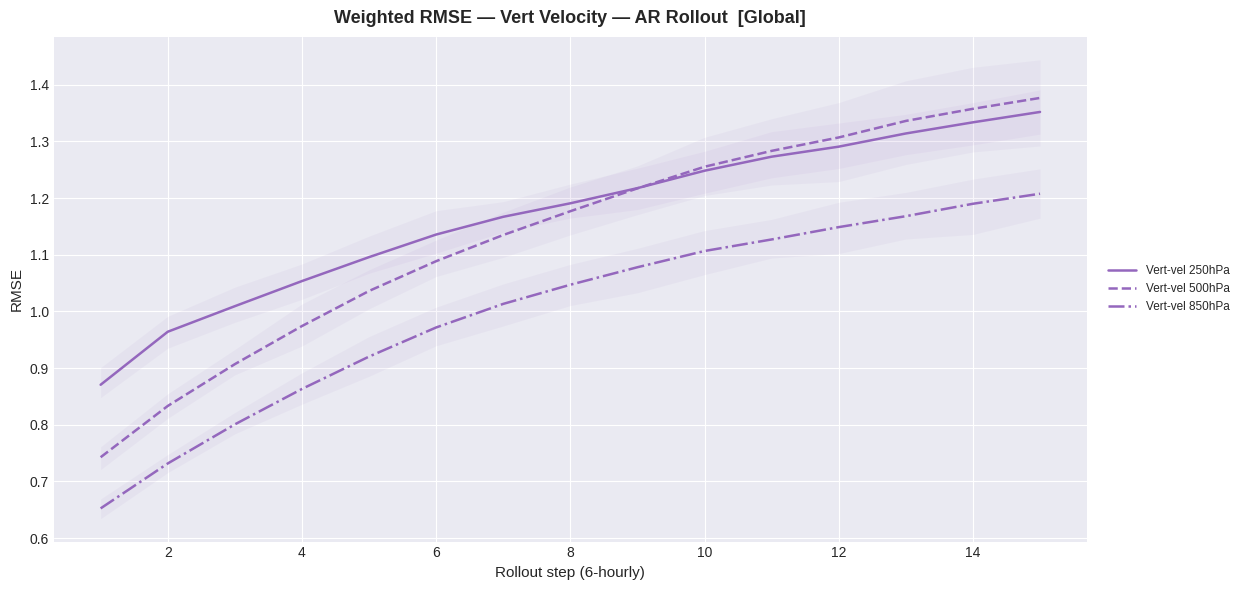

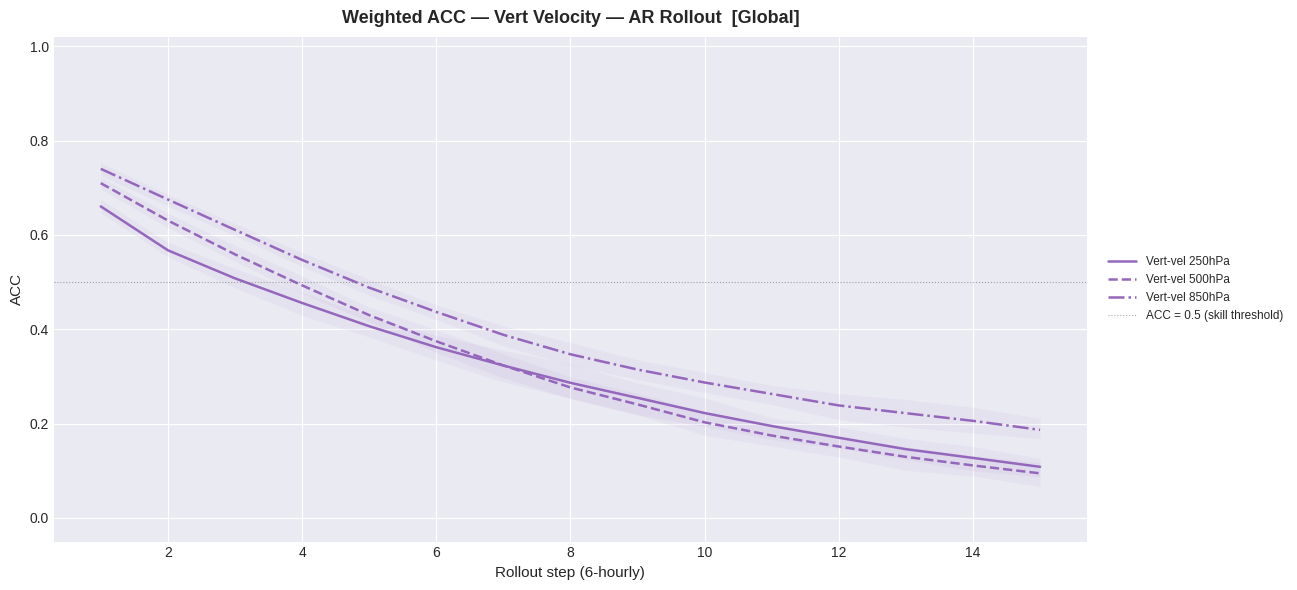

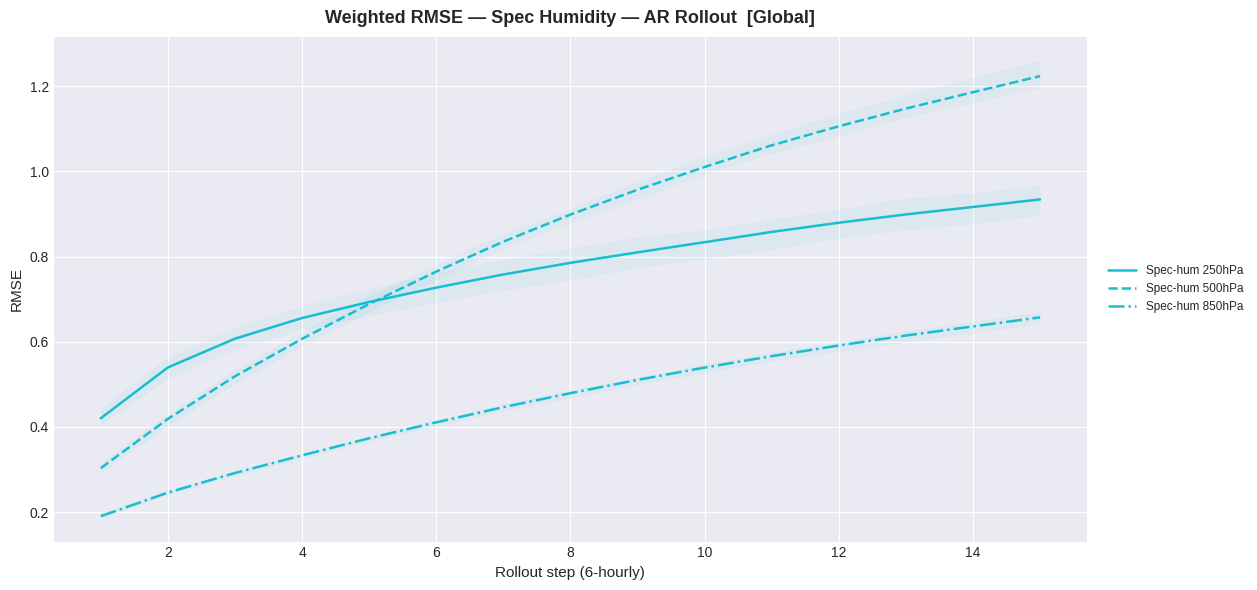

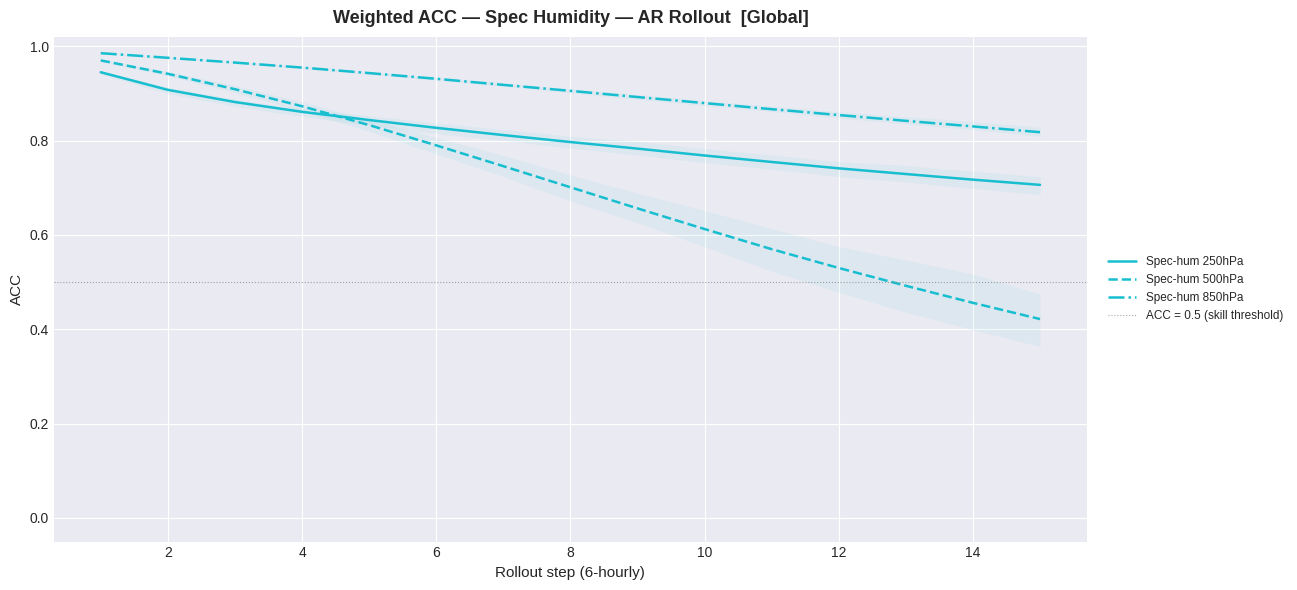

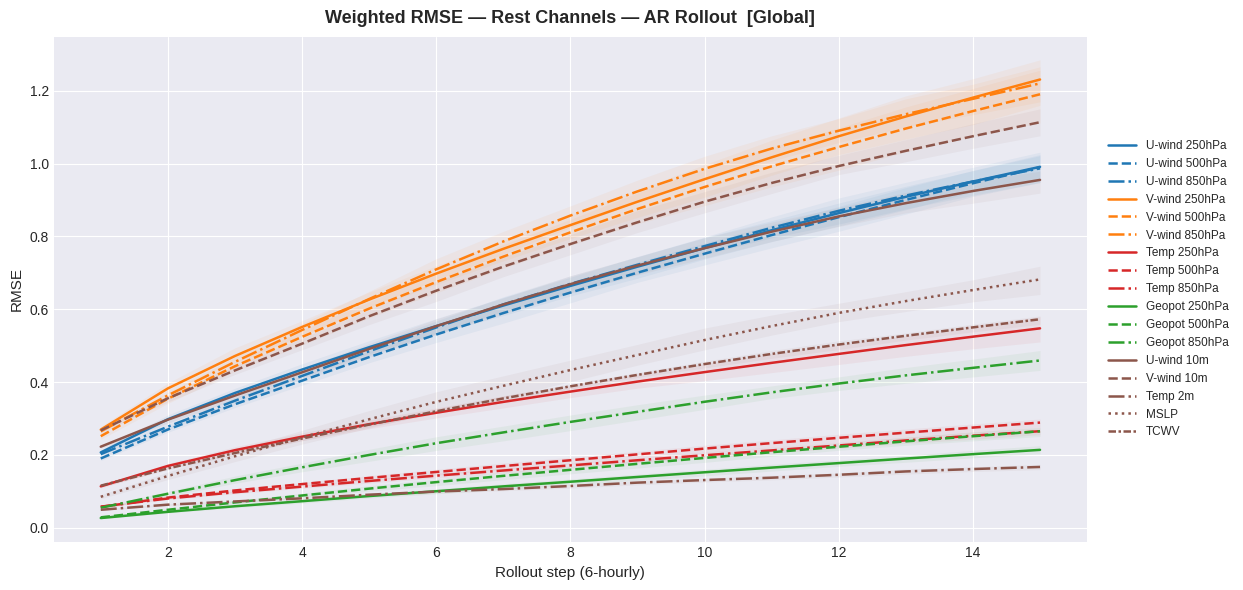

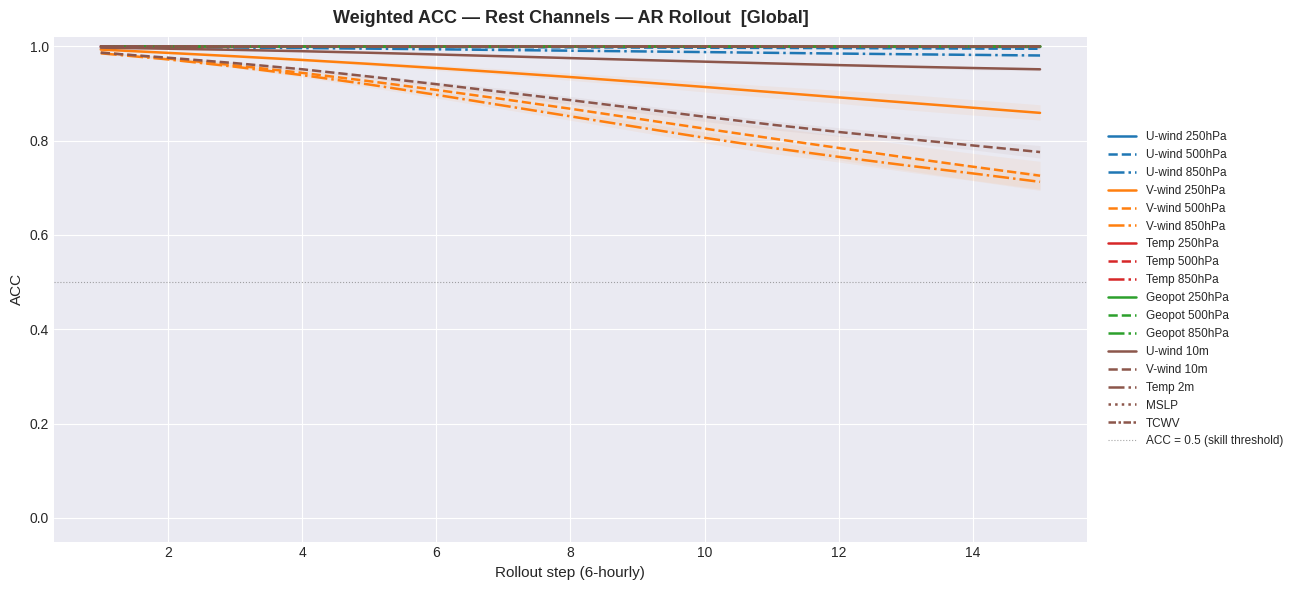

Done.


In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from matplotlib.ticker import MaxNLocator

plt.style.use('seaborn-v0_8-darkgrid')

BAND_COL = '#cfe2f3'

CHANNEL_NAMES = [
    'u_wind_250', 'u_wind_500', 'u_wind_850',
    'v_wind_250', 'v_wind_500', 'v_wind_850',
    'temp_250',   'temp_500',   'temp_850',
    'z_250',      'z_500',      'z_850',
    'w_250',      'w_500',      'w_850',
    'q_250',      'q_500',      'q_850',
    'u10m',       'v10m',       't2m',
    'mslp',       'tcwv',
]
CHANNEL_LABELS = [
    'U-wind 250hPa',   'U-wind 500hPa',   'U-wind 850hPa',
    'V-wind 250hPa',   'V-wind 500hPa',   'V-wind 850hPa',
    'Temp 250hPa',     'Temp 500hPa',     'Temp 850hPa',
    'Geopot 250hPa',   'Geopot 500hPa',   'Geopot 850hPa',
    'Vert-vel 250hPa', 'Vert-vel 500hPa', 'Vert-vel 850hPa',
    'Spec-hum 250hPa', 'Spec-hum 500hPa', 'Spec-hum 850hPa',
    'U-wind 10m',      'V-wind 10m',      'Temp 2m',
    'MSLP',            'TCWV',
]

# ── Group definitions ────────────────────────────────────────────────────────
GROUPS = {
    'U-wind':      ([0, 1, 2],    '#1f77b4'),  # blue family
    'V-wind':      ([3, 4, 5],    '#ff7f0e'),  # orange family
    'Temperature': ([6, 7, 8],    '#d62728'),  # red family
    'Geopotential':([9,10,11],    '#2ca02c'),  # green family
    'Vert-vel':    ([12,13,14],   '#9467bd'),  # purple family
    'Spec-hum':    ([15,16,17],   '#17becf'),  # cyan family
    'Surface':     ([18,19,20,21,22], '#8c564b'),  # brown family
}

# ── 3 Subsets for 3 Different Plots ──────────────────────────────────────────
SUBSET_VERT_VEL = {'Vert-vel': GROUPS['Vert-vel']}
SUBSET_SPEC_HUM = {'Spec-hum': GROUPS['Spec-hum']}
SUBSET_REST     = {k: v for k, v in GROUPS.items() if k not in ['Vert-vel', 'Spec-hum']}

PLOT_SUBSETS = {
    'Vert_Velocity': SUBSET_VERT_VEL,
    'Spec_Humidity': SUBSET_SPEC_HUM,
    'Rest_Channels': SUBSET_REST
}

LINESTYLES = ['-', '--', '-.', ':', (0,(3,1,1,1))]


def plot_channel_groups(matrix, metric_name, groups_dict, subset_name,
                        channel_labels=CHANNEL_LABELS,
                        rollout_steps=None,
                        save_path=None,
                        india_mask=False,
                        figsize=(14, 6)):
    """
    Plot selected channel groups on a single axes.
    """
    if rollout_steps is None:
        rollout_steps = matrix.shape[1]

    mean  = matrix.mean(axis=0)            # (steps, C)
    p25   = np.percentile(matrix, 25, axis=0)
    p75   = np.percentile(matrix, 75, axis=0)
    steps = np.arange(1, rollout_steps + 1)

    fig, ax = plt.subplots(figsize=figsize)

    for group_name, (indices, base_color) in groups_dict.items():
        for rank, c in enumerate(indices):
            ls    = LINESTYLES[rank % len(LINESTYLES)]
            label = channel_labels[c]
            # Plot the mean line
            ax.plot(steps, mean[:, c],
                    color=base_color, linestyle=ls,
                    linewidth=1.8, label=label,
                    solid_capstyle='round')
            # Plot the shaded confidence interval / variance
            ax.fill_between(steps, p25[:, c], p75[:, c],
                            color=base_color, alpha=0.06, linewidth=0)

    ax.set_xlabel('Rollout step (6-hourly)', fontsize=11)
    ax.set_ylabel(metric_name, fontsize=11)
    
    region = 'India region' if india_mask else 'Global'
    title  = f'Weighted {metric_name} — {subset_name.replace("_", " ")} — AR Rollout  [{region}]'
    ax.set_title(title, fontsize=13, fontweight='bold', pad=10)

    if metric_name == 'ACC':
        ax.set_ylim(-0.05, 1.02)
        ax.axhline(0.5, color='grey', lw=0.8, ls=':', alpha=0.7,
                   label='ACC = 0.5 (skill threshold)') # Note: changed text to 0.5 to match line

    ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=8))
    ax.ticklabel_format(style='plain', axis='y')

    # ── Legend outside right ────────────────────────────────────────
    leg = ax.legend(loc='center left', bbox_to_anchor=(1.01, 0.5),
                    fontsize=8.5, framealpha=0.9,
                    ncol=1, handlelength=2.4)

    plt.tight_layout()
    fig.subplots_adjust(right=0.78)   # make room for the legend

    if save_path:
        fig.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f'Saved → {save_path}')

    return fig


# ── Quick smoke-test with random data ────────────────────────────────────────
if __name__ == '__main__':
    # train_type = "dummy" # Placeholder for your actual variable
    # India_mask = False   # Placeholder for your actual variable
    
    OUT_BASE = f'eval_results_{train_type}train_split'
    DIR_RMSE = os.path.join(OUT_BASE, 'rmse')
    DIR_ACC  = os.path.join(OUT_BASE, 'acc')
    os.makedirs(DIR_RMSE, exist_ok=True)
    os.makedirs(DIR_ACC,  exist_ok=True)

    ROLLOUT_STEPS = 15
    NUM_SAMPLES   = 100
    C             = len(CHANNEL_NAMES)

    # ── load real matrices if available, else generate random ones ──
    rmse_path = f'rollout_rmse_India_{India_mask}_{train_type}train.npy'
    acc_path  = f'rollout_acc_India_{India_mask}_{train_type}train.npy'

    if os.path.exists(rmse_path) and os.path.exists(acc_path):
        rmse_matrix = np.load(rmse_path)
        acc_matrix  = np.load(acc_path)
        print('Loaded saved matrices.')
    else:
        print('No saved matrices found — using random data for smoke-test.')
        rng         = np.random.default_rng(0)
        rmse_matrix = rng.uniform(0.1, 3.0, (NUM_SAMPLES, ROLLOUT_STEPS, C))
        # simulate ACC decaying from ~1 to ~0 over rollout steps
        decay       = np.linspace(1.0, 0.1, ROLLOUT_STEPS)[None, :, None]
        acc_matrix  = np.clip(decay + rng.normal(0, 0.05, (NUM_SAMPLES, ROLLOUT_STEPS, C)), -1, 1)

    # ── Loop through subsets and generate 3 plots for RMSE and 3 for ACC ──
    for subset_name, subset_dict in PLOT_SUBSETS.items():
        
        # Plot RMSE
        plot_channel_groups(
            matrix=rmse_matrix,
            metric_name='RMSE',
            groups_dict=subset_dict,
            subset_name=subset_name,
            save_path=os.path.join(DIR_RMSE, f'rmse_{subset_name}_India_{India_mask}.png'),
            india_mask=India_mask,
            rollout_steps=ROLLOUT_STEPS,
        )

        # Plot ACC
        plot_channel_groups(
            matrix=acc_matrix,
            metric_name='ACC',
            groups_dict=subset_dict,
            subset_name=subset_name,
            save_path=os.path.join(DIR_ACC, f'acc_{subset_name}_India_{India_mask}.png'),
            india_mask=India_mask,
            rollout_steps=ROLLOUT_STEPS,
        )

    plt.show()
    print('Done.')

In [21]:
"""
rollout_viz.py
==============
Standalone rollout visualization for SFNO (or any autoregressive model).

Outputs (all under OUT_DIR):
  all_vars/
    rollout_all_vars.gif          — one frame per timestep, all variables
  per_var/<varname>/
    <varname>.gif                 — one frame per timestep, single variable
    <varname>_t+01.png …          — static plot per rollout step
"""

import os
import io
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import imageio.v2 as imageio
import seaborn as sns
import xarray as xr
import torch
import dask

dask.config.set(scheduler='synchronous')

sns.set_theme(style="white", context="paper", font_scale=1.05)

# ─────────────────────────────────────────────
# USER CONFIG — edit these
# ─────────────────────────────────────────────

ZARR_PATH     = '/storage/vishnu/era5_stacked.zarr/'
CKPT_PATH     = 'sfno_phase1SPHERE_layernorm_10000.pth'
MEANS_PATH    = 'means_era5_dataset.npy'
STDS_PATH     = 'std_era5_dataset.npy'
DATE_SLICE    = ('2019-06-01', '2019-06-30')   # window to sample from
START_IDX     = 10                             # time index within the slice
ROLLOUT_LEN   = 14
DEVICE        = 'cuda:0' if torch.cuda.is_available() else 'cpu'

OUT_DIR       = 'rollout_viz_output'

CHANNEL_NAMES = [
    'u_wind_250', 'u_wind_500', 'u_wind_850',
    'v_wind_250', 'v_wind_500', 'v_wind_850',
    'temp_250',   'temp_500',   'temp_850',
    'z_250',      'z_500',      'z_850',
    'w_250',      'w_500',      'w_850',
    'q_250',      'q_500',      'q_850',
    'u10m',       'v10m',       't2m',
    'mslp',       'tcwv',
]
CHANNEL_LABELS = [
    'U-wind 250hPa',   'U-wind 500hPa',   'U-wind 850hPa',
    'V-wind 250hPa',   'V-wind 500hPa',   'V-wind 850hPa',
    'Temp 250hPa',     'Temp 500hPa',     'Temp 850hPa',
    'Geopot 250hPa',   'Geopot 500hPa',   'Geopot 850hPa',
    'Vert-vel 250hPa', 'Vert-vel 500hPa', 'Vert-vel 850hPa',
    'Spec-hum 250hPa', 'Spec-hum 500hPa', 'Spec-hum 850hPa',
    'U-wind 10m',      'V-wind 10m',      'Temp 2m',
    'MSLP',            'TCWV',
]
N_CHANNELS = len(CHANNEL_NAMES)

# ─────────────────────────────────────────────
# COLORMAP HELPERS
# ─────────────────────────────────────────────

CMAP_FIELD = "RdBu_r"    # zero-centered: blue=negative, white=zero, red=positive
CMAP_DIFF  = "RdBu_r"    # same for difference


def _sym_norm(data: np.ndarray):
    """Return a TwoSlopeNorm centred on 0 with symmetric limits."""
    vmax = float(np.nanpercentile(np.abs(data), 98))
    vmax = vmax if vmax > 0 else 1.0
    return mcolors.TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)


# ─────────────────────────────────────────────
# SINGLE-FRAME PLOT
# ─────────────────────────────────────────────

def make_frame(preds, truth, t, var_indices=None, var_labels=None):
    """
    Build a figure with 3 rows (pred / truth / diff) × len(var_indices) cols.

    Parameters
    ----------
    preds       : list of length rollout_len, each (1, C, H, W) numpy
    truth       : (C, T, H, W) numpy  (T = rollout_len+1, index 0 = initial)
    t           : rollout step (0-based)
    var_indices : list of channel indices to plot (None = all)
    var_labels  : matching display labels

    Returns
    -------
    fig : matplotlib Figure
    """
    if var_indices is None:
        var_indices = list(range(preds[0].shape[1]))
    if var_labels is None:
        var_labels = [CHANNEL_LABELS[i] for i in var_indices]

    nv     = len(var_indices)
    height = preds[0].shape[-2]
    width  = preds[0].shape[-1]
    lons   = np.linspace(0, 360, width)
    lats   = np.linspace(-90, 90, height)
    lon2d, lat2d = np.meshgrid(lons, lats)

    proj = ccrs.PlateCarree()
    fig, axes = plt.subplots(
        3, nv,
        figsize=(4.2 * nv, 9),
        subplot_kw={'projection': proj},
        gridspec_kw={'hspace': 0.45, 'wspace': 0.08},
    )
    if nv == 1:
        axes = axes[:, np.newaxis]

    row_labels = ['Prediction', 'Ground Truth', 'Difference (Truth − Pred)']

    for col, (cidx, clabel) in enumerate(zip(var_indices, var_labels)):
        pred_field  = preds[t][0, cidx]                             # (H, W)
        truth_field = np.asarray(truth[cidx, t + 1])                # (H, W)
        diff_field  = truth_field - pred_field

        # --- symmetric norms (zero = white) ---
        combined = np.concatenate([pred_field.ravel(), truth_field.ravel()])
        norm_field = _sym_norm(combined)
        norm_diff  = _sym_norm(diff_field)

        for row, (field, norm) in enumerate([
            (pred_field,  norm_field),
            (truth_field, norm_field),
            (diff_field,  norm_diff),
        ]):
            ax = axes[row, col]
            pcm = ax.pcolormesh(
                lon2d, lat2d, field,
                cmap=CMAP_FIELD, norm=norm,
                transform=proj, rasterized=True,
            )
            ax.coastlines(linewidth=0.5, color='#444')
            ax.set_global()
            cb = fig.colorbar(pcm, ax=ax, orientation='horizontal',
                              pad=0.04, fraction=0.046, aspect=28)
            cb.ax.tick_params(labelsize=6)

            if row == 0:
                ax.set_title(clabel, fontsize=8.5, fontweight='semibold', pad=4)
            if col == 0:
                ax.text(-0.10, 0.5, row_labels[row],
                        transform=ax.transAxes,
                        fontsize=8, rotation=90, va='center', ha='right',
                        color='#333')

    fig.suptitle(f'Rollout  t + {t + 1:02d}', fontsize=13,
                 fontweight='bold', y=1.01, color='#1a1a2e')
    return fig


# ─────────────────────────────────────────────
# UTILITIES
# ─────────────────────────────────────────────

def fig_to_image(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=200, bbox_inches='tight')
    buf.seek(0)
    img = imageio.imread(buf)
    buf.close()
    plt.close(fig)
    return img


def save_gif(frames, path, fps=2):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    imageio.mimsave(path, frames, fps=fps, loop=0)
    print(f'  GIF saved → {path}')


# ─────────────────────────────────────────────
# MAIN
# ─────────────────────────────────────────────

if __name__ == '__main__':
    import sys
    sys.path.insert(0, '.')
    from sfno import SphericalFourierNeuralOperatorNet as SFNO
    ROLLOUT_LEN = 14
    ar_steps = 14
    
    device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
    ds = xr.open_zarr('/storage/vishnu/era5_stacked.zarr/', chunks={})
    ds = ds.sel(time=slice('2019-01-01',None))


    
    prefetcher = ERA5Prefetcher(
            ds,
            batch_size=1,
            queue_size=1,
            sequence_length=ar_steps + 1,
            device=device,
            check_nans=False
            )
    
    prefetcher.start()
    batch = prefetcher.get()
    prefetcher.stop()

    print(f'Batch shape {batch.shape}')
    truth = batch[0]
    # ── model ─────────────────────────────────────────────────────
    model = SFNO(
        operator_type='driscoll-healy',
        img_size=(nlat, nlon),
        num_layers=8,
        scale_factor=2,
        embed_dim=384,
        pos_embed='latlon',
        use_mlp=True,
        activation_function='gelu',
        normalization_layer='layer_norm',
        hard_thresholding_fraction=1.0,
        in_chans=N_CHANNELS,
        out_chans=N_CHANNELS,
    ).to(DEVICE)

    if os.path.exists(CKPT_PATH):
        model.load_state_dict(torch.load(CKPT_PATH, map_location=DEVICE))
        print('Loaded checkpoint.')
    model.eval()

    # ── autoregressive rollout ────────────────────────────────────
    preds   = []
    current = batch[:, :, 0, :, :].to(DEVICE)
    for step in range(ROLLOUT_LEN):
        print(step, end=' ', flush=True)
        with torch.no_grad():
            pred = model(current)
        current = pred
        preds.append(pred.detach().cpu().numpy())   # (1, C, H, W)
    print()

    # ── all-variable GIF ─────────────────────────────────────────
    print('\nBuilding all-variable GIF …')
    all_frames = []
    for t in range(ROLLOUT_LEN):
        print(f'  frame t+{t+1}', end='\r', flush=True)
        fig = make_frame(preds, truth, t,
                         var_indices=list(range(N_CHANNELS)),
                         var_labels=CHANNEL_LABELS)
        all_frames.append(fig_to_image(fig))
    save_gif(all_frames,
             os.path.join(dir_all, 'rollout_all_vars.gif'), fps=2)

    # ── per-variable GIFs + static PNGs ──────────────────────────
    print('\nBuilding per-variable GIFs and PNGs …')
    for cidx, (cname, clabel) in enumerate(zip(CHANNEL_NAMES, CHANNEL_LABELS)):
        var_dir = os.path.join(dir_pervar, cname)
        os.makedirs(var_dir, exist_ok=True)

        var_frames = []
        for t in range(ROLLOUT_LEN):
            fig = make_frame(preds, truth, t,
                             var_indices=[cidx],
                             var_labels=[clabel])

            # static PNG for this (variable, rollout-step)
            png_path = os.path.join(var_dir, f'{cname}_t+{t+1:02d}.png')
            fig.savefig(png_path, dpi=110, bbox_inches='tight')
            var_frames.append(fig_to_image(fig))   # fig is closed inside

        save_gif(var_frames,
                 os.path.join(var_dir, f'{cname}.gif'), fps=2)
        print(f'  {cname}: {ROLLOUT_LEN} PNGs  saved')

    print(f'\nAll done!  Results in: {OUT_DIR}/')
    print(f'  {dir_all}/rollout_all_vars.gif')
    print(f'  {dir_pervar}/<varname>/<varname>.gif')
    print(f'  {dir_pervar}/<varname>/<varname>_t+NN.png')

[Worker 140437467465472] started
[1162]Batch shape torch.Size([1, 23, 15, 121, 240])
Loaded checkpoint.
0 1 2 3 4 5 6 7 8 9 10 11 12 13 

Building all-variable GIF …
  GIF saved → rollout_viz_output/all_vars/rollout_all_vars.gif

Building per-variable GIFs and PNGs …
  GIF saved → rollout_viz_output/per_var/u_wind_250/u_wind_250.gif
  u_wind_250: 14 PNGs  saved
  GIF saved → rollout_viz_output/per_var/u_wind_500/u_wind_500.gif
  u_wind_500: 14 PNGs  saved
  GIF saved → rollout_viz_output/per_var/u_wind_850/u_wind_850.gif
  u_wind_850: 14 PNGs  saved
  GIF saved → rollout_viz_output/per_var/v_wind_250/v_wind_250.gif
  v_wind_250: 14 PNGs  saved
  GIF saved → rollout_viz_output/per_var/v_wind_500/v_wind_500.gif
  v_wind_500: 14 PNGs  saved
  GIF saved → rollout_viz_output/per_var/v_wind_850/v_wind_850.gif
  v_wind_850: 14 PNGs  saved
  GIF saved → rollout_viz_output/per_var/temp_250/temp_250.gif
  temp_250: 14 PNGs  saved
  GIF saved → rollout_viz_output/per_var/temp_500/temp_500.gif
  t

In [ ]:
# import os
# import numpy as np
# import torch
# import xarray as xr
# import matplotlib.pyplot as plt
# import matplotlib.gridspec as gridspec
# from matplotlib.ticker import MaxNLocator
# from tqdm import tqdm
# import xarray as xr
# import torch
# import torch.nn as nn
# import torch.optim as optim
# from torch.utils.data import Dataset, DataLoader
# from torch.optim.lr_scheduler import LinearLR, SequentialLR
# from torch.nn.parallel import DistributedDataParallel as DDP
# import torch.distributed as dist
# from torch.utils.data.distributed import DistributedSampler
# from tqdm import tqdm
# import numpy as np
# import argparse
# from sfno import SphericalFourierNeuralOperatorNet as SFNO

# import matplotlib.pyplot as plt
# torch.autograd.set_detect_anomaly(True)
# import matplotlib.pyplot as plt
# import cartopy.crs as ccrs
# import imageio.v2 as imageio
# import io
# from scipy import stats

# from latweightedloss import LatWeightedLoss
# import threading
# import queue
# import numpy as np
# import xarray as xr
# import torch
# import time
# import dask

# dask.config.set(scheduler='synchronous')


# # ─────────────────────────────────────────────
# # ERA5 PREFETCHER
# # ─────────────────────────────────────────────

# class ERA5Prefetcher:
#     def __init__(self, ds, batch_size, queue_size=4, sequence_length=14, device="cpu",
#                  check_nans=False, normalize=True,
#                  means='means_era5_dataset.npy', stds='std_era5_dataset.npy'):
#         self.ds = ds
#         self.B = batch_size
#         self.time_max = self.ds.time.size - sequence_length
#         self.queue = queue.Queue(maxsize=queue_size)
#         self.device = device
#         self.seq_len = sequence_length
#         self.stop_event = threading.Event()
#         self.thread = threading.Thread(target=self._worker, daemon=True)
#         self.valid_indices = self.get_valid_indices()
#         self.check_nans = check_nans
#         self.normalize = normalize
#         if self.normalize:
#             self.means = np.load(means)
#             self.stds = np.load(stds)

#     def get_valid_indices(self):
#         time_max = self.time_max
#         nan_times = np.load('nan_times.npy')
#         offsets = np.arange(-self.seq_len - 1, self.seq_len + 1)
#         masks = np.unique((nan_times[:, None] + offsets[None, :]).flatten())
#         arr = np.arange(time_max)
#         masks = masks[(masks <= time_max)]
#         arr[masks] = -1
#         arr = arr[(arr >= 0) & (arr < time_max)]
#         return np.unique(arr)

#     def start(self):
#         self.thread.start()

#     def stop(self):
#         self.stop_event.set()
#         while not self.queue.empty():
#             try:
#                 self.queue.get_nowait()
#             except queue.Empty:
#                 break
#         self.thread.join()

#     def _worker(self):
#         worker_id = threading.get_ident()
#         print(f"[Worker {worker_id}] started")
#         while not self.stop_event.is_set():
#             if self.queue.full():
#                 time.sleep(0.01)
#                 continue
#             loc = np.random.choice(self.valid_indices, size=self.B)
#             print(loc, end='')
#             time_idx = loc[:, None] + np.arange(self.seq_len)[None, :]
#             try:
#                 batch_view = self.ds['era5_features'].isel(
#                     time=xr.DataArray(time_idx, dims=("batch", "step"))
#                 ).transpose("batch", "channel", "step", "latitude", "longitude")

#                 if self.normalize:
#                     numpy_batch = batch_view.values
#                     means = np.expand_dims(self.means, axis=(2, 3, 4))
#                     stds = np.expand_dims(self.stds, axis=(2, 3, 4))
#                     numpy_batch = (numpy_batch - means) / stds
#                 else:
#                     numpy_batch = batch_view.values

#                 if self.check_nans:
#                     if np.isnan(numpy_batch).any():
#                         print('!!!! Error nan found.')
#                         np.save('time_ids_for_nans.npy', time_idx)

#                 tensor = torch.from_numpy(numpy_batch).contiguous().float()
#                 if torch.cuda.is_available():
#                     tensor = tensor.pin_memory()
#                 self.queue.put(tensor)

#             except Exception as e:
#                 print(f"Worker Error: {e}")
#                 self.stop_event.set()

#     def get(self):
#         return self.queue.get(timeout=600)


# # ─────────────────────────────────────────────
# # CONFIG
# # ─────────────────────────────────────────────

# ROLLOUT_STEPS = 15
# BATCH_SIZE    = 1
# NUM_SAMPLES   = 100
# DEVICE        = 'cuda:0' if torch.cuda.is_available() else 'cpu'

# CHANNEL_NAMES = [
#     'u_wind_250', 'u_wind_500', 'u_wind_850',
#     'v_wind_250', 'v_wind_500', 'v_wind_850',
#     'temp_250',   'temp_500',   'temp_850',
#     'z_250',      'z_500',      'z_850',
#     'w_250',      'w_500',      'w_850',
#     'q_250',      'q_500',      'q_850',
#     'u10m',       'v10m',       't2m',
#     'mslp',       'tcwv',
# ]
# CHANNEL_LABELS = [
#     'U-wind 250hPa',   'U-wind 500hPa',   'U-wind 850hPa',
#     'V-wind 250hPa',   'V-wind 500hPa',   'V-wind 850hPa',
#     'Temp 250hPa',     'Temp 500hPa',     'Temp 850hPa',
#     'Geopot 250hPa',   'Geopot 500hPa',   'Geopot 850hPa',
#     'Vert-vel 250hPa', 'Vert-vel 500hPa', 'Vert-vel 850hPa',
#     'Spec-hum 250hPa', 'Spec-hum 500hPa', 'Spec-hum 850hPa',
#     'U-wind 10m',      'V-wind 10m',      'Temp 2m',
#     'MSLP',            'TCWV',
# ]
# N_CHANNELS = len(CHANNEL_NAMES)

# # Output directories
# OUT_BASE  = 'eval_results'
# DIR_RMSE  = os.path.join(OUT_BASE, 'rmse')
# DIR_ACC   = os.path.join(OUT_BASE, 'acc')
# DIR_POWER = os.path.join(OUT_BASE, 'power')

# for d in [DIR_RMSE, DIR_ACC, DIR_POWER]:
#     os.makedirs(d, exist_ok=True)


# # ─────────────────────────────────────────────
# # HELPERS
# # ─────────────────────────────────────────────

# def lat_weights(num_lat: int, device='cpu') -> torch.Tensor:
#     lat_t  = torch.arange(num_lat, dtype=torch.float32, device=device)
#     interm = 90.0 - lat_t * 180.0 / float(num_lat - 1)
#     cos    = torch.cos(torch.deg2rad(interm))
#     w      = num_lat * cos / cos.sum()
#     return w.reshape(1, -1, 1)


# def weighted_rmse(pred, truth, india_mask=False,
#                   hslice=slice(64, 85), wslice=slice(40, 65)):
#     w = lat_weights(pred.shape[1], device=pred.device)
#     if india_mask:
#         pred  = pred[:,  hslice, wslice]
#         truth = truth[:, hslice, wslice]
#         w     = w[:, hslice, :]
#     return torch.sqrt(torch.mean(w * (pred - truth) ** 2, dim=(-1, -2)))


# def weighted_acc(pred, truth, clim_mean, india_mask=False,
#                  hslice=slice(64, 85), wslice=slice(40, 65)):
#     p = (pred  - clim_mean)
#     t = (truth - clim_mean)
#     w = lat_weights(p.shape[1], device=pred.device)
#     if india_mask:
#         p = p[:,  hslice, wslice]
#         t = t[:, hslice, wslice]
#         w = w[:, hslice, :]
#     num   = torch.sum(w * p * t,           dim=(-1, -2))
#     denom = torch.sqrt(torch.sum(w * p * p, dim=(-1, -2)) *
#                        torch.sum(w * t * t, dim=(-1, -2)))
#     return num / (denom + 1e-12)


# # ─────────────────────────────────────────────
# # POWER SPECTRUM
# # ─────────────────────────────────────────────

# def spherical_power_spectrum_fft(field: np.ndarray):
#     """
#     Approximate spherical power spectrum via 2-D FFT with cosine-latitude
#     weighting.  Bins into annuli of radius |k|.

#     Parameters
#     ----------
#     field : ndarray (lat, lon)

#     Returns
#     -------
#     wavenumbers : ndarray
#     power       : ndarray
#     """
#     nlat, nlon = field.shape
#     lats    = np.linspace(90, -90, nlat, endpoint=False) * np.pi / 180.0
#     cos_lat = np.cos(lats)[:, None]
#     weighted = field * np.sqrt(cos_lat)
#     F  = np.fft.fft2(weighted)
#     amplitude2 = np.abs(F) ** 2 / (nlat * nlon) ** 2
#     kx = np.fft.fftfreq(nlon) * nlon
#     ky = np.fft.fftfreq(nlat) * nlat
#     KX, KY = np.meshgrid(kx, ky)
#     K = np.sqrt(KX ** 2 + KY ** 2).ravel()
#     A = amplitude2.ravel()
#     kmax  = int(min(nlon, nlat) // 2)
#     kbins = np.arange(0.5, kmax + 1.5, 1.0)
#     kvals = 0.5 * (kbins[1:] + kbins[:-1])
#     power, _, _ = stats.binned_statistic(K, A, statistic="sum", bins=kbins)
#     return kvals, power


# # ─────────────────────────────────────────────
# # ROLLOUT EVALUATION
# # ─────────────────────────────────────────────

# def evaluate_rollout(model, prefetcher, time_means, time_stds,
#                      num_samples=NUM_SAMPLES, rollout_steps=ROLLOUT_STEPS,
#                      device=DEVICE, india_mask=False):
#     """
#     Returns
#     -------
#     rmse_matrix  : (num_samples, rollout_steps, C)
#     acc_matrix   : (num_samples, rollout_steps, C)
#     pred_samples : list of (C, lat, lon) tensors — final-step predictions
#     gt_samples   : list of (C, lat, lon) tensors — final-step ground truth
#     """
#     model.eval()
#     clim_mean = torch.from_numpy(time_means)[0,:,:,:].to(device)

#     rmse_all, acc_all = [], []
#     pred_samples, gt_samples = [], []

#     for sample_i in tqdm(range(num_samples), desc="Evaluating rollout"):
#         batch = prefetcher.get().to(device)   # (1, C, T, lat, lon)

#         sample_rmse, sample_acc = [], []
#         x = batch[:, :, 0, :, :]              # (1, C, lat, lon)

#         for step in range(rollout_steps):
#             with torch.no_grad():
#                 pred_norm = model(x)

#             gt_norm = batch[:, :, step + 1, :, :]

#             rmse_step = weighted_rmse(
#                 pred_norm[0], gt_norm[0], india_mask=india_mask
#             ).detach().cpu().numpy()

#             acc_step = weighted_acc(
#                 pred_norm[0], gt_norm[0], clim_mean, india_mask=india_mask
#             ).detach().cpu().numpy()

#             sample_rmse.append(rmse_step)
#             sample_acc.append(acc_step)
#             x = pred_norm.detach()

#         rmse_all.append(sample_rmse)
#         acc_all.append(sample_acc)

#         # store final-step pred & gt for power-spectrum computation
#         pred_samples.append(pred_norm[0].detach().cpu())
#         gt_samples.append(gt_norm[0].detach().cpu())

#     return (np.array(rmse_all), np.array(acc_all),
#             pred_samples, gt_samples)


# # ─────────────────────────────────────────────
# # STYLE HELPERS
# # ─────────────────────────────────────────────

# BG_DARK    = '#0d1117'
# AX_DARK    = '#161b22'
# ACCENT     = '#00d4aa'
# GRID_COL   = '#1e2a35'
# TEXT_COL   = '#c9d1d9'
# TITLE_COL  = '#ffffff'
# BAND_COL   = '#00d4aa33'


# def _style_ax(ax):
#     ax.set_facecolor(AX_DARK)
#     ax.tick_params(colors=TEXT_COL, labelsize=7.5)
#     for sp in ax.spines.values():
#         sp.set_edgecolor(GRID_COL)
#     ax.grid(color=GRID_COL, linewidth=0.6)


# # ─────────────────────────────────────────────
# # RMSE / ACC PLOTTING
# # ─────────────────────────────────────────────

# def _plot_single_channel(steps, mean_c, p25_c, p75_c, label, metric_name):
#     """Return a Figure with a single channel metric curve."""
#     fig, ax = plt.subplots(figsize=(5, 3.5) )  #facecolor=BG_DARK
#     _style_ax(ax)
#     ax.plot(steps, mean_c, color=ACCENT, linewidth=2.2, solid_capstyle='round')
#     ax.fill_between(steps, p25_c, p75_c, color=BAND_COL, linewidth=0)
#     ax.set_title(label, color=TITLE_COL, fontsize=11, fontweight='bold', pad=6)
#     ax.set_xlabel('Rollout step', color=TEXT_COL, fontsize=9)
#     ax.set_ylabel(metric_name, color=TEXT_COL, fontsize=9)
#     if metric_name == 'ACC':
#         ax.set_ylim(-1, 1)
#     ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))
#     ax.ticklabel_format(style='plain', axis='y')
#     plt.tight_layout()
#     return fig


# def plot_metric_grid(matrix, metric_name, channel_labels=CHANNEL_LABELS,
#                      rollout_steps=ROLLOUT_STEPS, save_path=None, India_mask=False):
#     """
#     Grid of all channels.
#     matrix : (num_samples, rollout_steps, C)
#     """
#     mean  = matrix.mean(axis=0)
#     p25   = np.percentile(matrix, 25, axis=0)
#     p75   = np.percentile(matrix, 75, axis=0)
#     steps = np.arange(1, rollout_steps + 1)
#     C     = mean.shape[1]
#     NCOLS = 4
#     NROWS = (C + NCOLS - 1) // NCOLS

#     fig = plt.figure(figsize=(NCOLS * 4.5, NROWS * 3.2)) #facecolor=BG_DARK
#     gs  = gridspec.GridSpec(NROWS, NCOLS, figure=fig, hspace=0.55, wspace=0.35)

#     for c in range(C):
#         row, col = divmod(c, NCOLS)
#         ax = fig.add_subplot(gs[row, col])
#         _style_ax(ax)
#         ax.plot(steps, mean[:, c], color=ACCENT,
#                 linewidth=2.0, solid_capstyle='round')
#         ax.fill_between(steps, p25[:, c], p75[:, c],
#                         color=BAND_COL, linewidth=0)
#         ax.set_title(channel_labels[c], color=TITLE_COL,
#                      fontsize=9.5, fontweight='bold', pad=6)
#         ax.set_xlabel('Rollout step', color=TEXT_COL, fontsize=7.5)
#         ax.set_ylabel(metric_name,    color=TEXT_COL, fontsize=7.5)
#         if metric_name == 'ACC':
#             ax.set_ylim(-1, 1)
#         ax.ticklabel_format(style='plain', axis='y')
#         ax.xaxis.set_major_locator(MaxNLocator(integer=True, nbins=5))

#     for c in range(C, NROWS * NCOLS):
#         row, col = divmod(c, NCOLS)
#         fig.add_subplot(gs[row, col]).set_visible(False)

#     sup = ('Weighted RMSE per Channel — AR Rollout'
#            if metric_name == 'RMSE'
#            else 'Weighted ACC per Channel — AR Rollout')
#     fig.suptitle(sup, color=TITLE_COL, fontsize=15, fontweight='bold', y=1.01)
#     plt.tight_layout()

#     if save_path:
#         fig.savefig(save_path, dpi=150, bbox_inches='tight',
#                     facecolor=fig.get_facecolor())
#         print(f'Saved → {save_path}')
#     plt.close(fig)


# def save_metric_per_variable(matrix, metric_name, out_dir,
#                               channel_names=CHANNEL_NAMES,
#                               channel_labels=CHANNEL_LABELS,
#                               rollout_steps=ROLLOUT_STEPS,
#                               India_mask=False):
#     """
#     Save one plot per variable inside `out_dir`.
#     """
#     mean  = matrix.mean(axis=0)
#     p25   = np.percentile(matrix, 25, axis=0)
#     p75   = np.percentile(matrix, 75, axis=0)
#     steps = np.arange(1, rollout_steps + 1)

#     for c, (cname, clabel) in enumerate(zip(channel_names, channel_labels)):
#         fig = _plot_single_channel(
#             steps, mean[:, c], p25[:, c], p75[:, c], clabel, metric_name
#         )
#         fname = os.path.join(out_dir, f'{metric_name.lower()}_{cname}_India_{India_mask}.png')
#         fig.savefig(fname, dpi=150, bbox_inches='tight',
#                     facecolor=fig.get_facecolor())
#         plt.close(fig)
#         print(f'  Saved → {fname}')


# # ─────────────────────────────────────────────
# # POWER SPECTRUM PLOTTING
# # ─────────────────────────────────────────────

# def _plot_power_single(wn_truth, P_truth, wn_pred, P_pred,
#                        channel_label, channel_name):
#     """Return a Figure with the power spectrum for one variable."""
#     fig, ax = plt.subplots(figsize=(7, 4),)
#     _style_ax(ax)
#     ax.loglog(wn_truth[1:], P_truth[1:], color='#ffffff',
#               lw=2.2, ls='-',  label='ERA5 (truth)')
#     ax.loglog(wn_pred[1:],  P_pred[1:],  color='#4fc3f7',
#               lw=1.8, ls='--', label='Model')

#     for n_label, scale_km in [(10, '4000 km'), (40, '1000 km'), (200, '200 km')]:
#         ax.axvline(n_label, color='#555', lw=0.8, ls=':')

#     ax.set_xlabel('Total Spherical Wavenumber  n', color=TEXT_COL, fontsize=10)
#     ax.set_ylabel('Power Spectral Density  P(n)', color=TEXT_COL, fontsize=10)
#     ax.set_title(f'Power Spectrum  –  {channel_label}',
#                  color=TITLE_COL, fontsize=11, pad=8)
#     ax.legend(facecolor='#1a1f2b', edgecolor='#444',
#               labelcolor='white', fontsize=9)
#     ax.tick_params(colors=TEXT_COL)
#     plt.tight_layout()
#     return fig


# def plot_power_spectra_grid(wn_truth_all, P_truth_all,
#                             wn_pred_all, P_pred_all,
#                             channel_labels=CHANNEL_LABELS,
#                             channel_names=CHANNEL_NAMES,
#                             save_path=None):
#     """
#     Grid of power spectra for all channels.
#     *_all : list of length C, each element is a 1-D array.
#     """
#     C     = len(channel_labels)
#     NCOLS = 4
#     NROWS = (C + NCOLS - 1) // NCOLS

#     fig = plt.figure(figsize=(NCOLS * 5, NROWS * 3.5)) # facecolor=BG_DARK
#     gs  = gridspec.GridSpec(NROWS, NCOLS, figure=fig, hspace=0.6, wspace=0.4)

#     for c in range(C):
#         row, col = divmod(c, NCOLS)
#         ax = fig.add_subplot(gs[row, col])
#         _style_ax(ax)

#         wt, Pt = wn_truth_all[c], P_truth_all[c]
#         wp, Pp = wn_pred_all[c],  P_pred_all[c]

#         ax.loglog(wt[1:], Pt[1:], color='#ffffff', lw=1.8, ls='-',  label='ERA5')
#         ax.loglog(wp[1:], Pp[1:], color='#4fc3f7', lw=1.5, ls='--', label='Model')
#         ax.set_title(channel_labels[c], color=TITLE_COL,
#                      fontsize=9, fontweight='bold', pad=5)
#         ax.set_xlabel('Wavenumber', color=TEXT_COL, fontsize=7)
#         ax.set_ylabel('PSD', color=TEXT_COL, fontsize=7)
#         ax.legend(facecolor='#1a1f2b', edgecolor='#444',
#                   labelcolor='white', fontsize=7)

#     for c in range(C, NROWS * NCOLS):
#         row, col = divmod(c, NCOLS)
#         fig.add_subplot(gs[row, col]).set_visible(False)

#     fig.suptitle('Power Spectrum per Channel', color=TITLE_COL,
#                  fontsize=15, fontweight='bold', y=1.01)
#     plt.tight_layout()

#     if save_path:
#         fig.savefig(save_path, dpi=150, bbox_inches='tight',
#                     facecolor=fig.get_facecolor())
#         print(f'Saved → {save_path}')
#     plt.close(fig)


# def save_power_spectra_per_variable(wn_truth_all, P_truth_all,
#                                     wn_pred_all, P_pred_all,
#                                     out_dir,
#                                     channel_labels=CHANNEL_LABELS,
#                                     channel_names=CHANNEL_NAMES):
#     """Save one power-spectrum plot per variable into out_dir."""
#     for c, (cname, clabel) in enumerate(zip(channel_names, channel_labels)):
#         fig = _plot_power_single(
#             wn_truth_all[c], P_truth_all[c],
#             wn_pred_all[c],  P_pred_all[c],
#             clabel, cname
#         )
#         fname = os.path.join(out_dir, f'power_{cname}.png')
#         fig.savefig(fname, dpi=150, bbox_inches='tight',
#                     facecolor=fig.get_facecolor())
#         plt.close(fig)
#         print(f'  Saved → {fname}')


# # ─────────────────────────────────────────────
# # MAIN
# # ─────────────────────────────────────────────

# if __name__ == '__main__':
#     import sys
#     sys.path.insert(0, '.')

#     time_means = np.load('means_era5_dataset.npy')   # (C,)
#     time_stds  = np.load('std_era5_dataset.npy')     # (C,)
#     clim_means = np.load('clim.npy')
#     ds = xr.open_zarr('/storage/vishnu/era5_stacked.zarr/', chunks={})
#     ds = ds.sel(time=slice('2019-01-01', '2019-12-31'))
   
#     prefetcher = ERA5Prefetcher(
#         ds,
#         batch_size=BATCH_SIZE,
#         queue_size=4,
#         sequence_length=ROLLOUT_STEPS + 1,
#         device=DEVICE,
#         check_nans=False,
#         normalize=True,
#     )
#     prefetcher.start()

#     nlat, nlon = ds.latitude.size, ds.longitude.size
#     model = SFNO(
#         operator_type='driscoll-healy',
#         img_size=(nlat, nlon),
#         num_layers=8,
#         scale_factor=2,
#         embed_dim=384,
#         pos_embed='latlon',
#         use_mlp=True,
#         activation_function='gelu',
#         normalization_layer='layer_norm',
#         hard_thresholding_fraction=1.0,
#         in_chans=N_CHANNELS,
#         out_chans=N_CHANNELS,
#     ).to(DEVICE)

#     ckpt = 'sfno_phase1SPHERE_layernorm_10000.pth'
#     if os.path.exists(ckpt):
#         model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
#         print('Loaded checkpoint.')

#     India_mask = False
#     # ── Rollout evaluation ─────────────────────────────────────────
#     rmse_matrix, acc_matrix, pred_samples, gt_samples = evaluate_rollout(
#         model, prefetcher, clim_means, time_stds,
#         num_samples=NUM_SAMPLES,
#         rollout_steps=ROLLOUT_STEPS,
#         device=DEVICE,
#         india_mask=India_mask,
#     )
#     prefetcher.stop()

#     np.save(f'rollout_rmse_India_{India_mask}.npy', rmse_matrix)
#     np.save(f'rollout_acc_India_{India_mask}.npy',  acc_matrix)
#     print(f'Saved rollout_rmse_India_{India_mask}.npy and rollout_acc_India_{India_mask}.npy')

#     # ── RMSE: grid + per-variable ──────────────────────────────────
#     print('\n── RMSE plots ──')
#     plot_metric_grid(rmse_matrix, 'RMSE',
#                      save_path=os.path.join(DIR_RMSE, f'rmse_all_channels_India_{India_mask}.png'))
#     save_metric_per_variable(rmse_matrix, 'RMSE', DIR_RMSE, India_mask = India_mask)

#     # ── ACC: grid + per-variable ───────────────────────────────────
#     print('\n── ACC plots ──')
#     plot_metric_grid(acc_matrix, 'ACC',
#                      save_path=os.path.join(DIR_ACC, f'acc_all_channels_India_{India_mask}.png'))
#     save_metric_per_variable(acc_matrix, 'ACC', DIR_ACC, India_mask = India_mask)

#     # ── Power spectra: compute, grid + per-variable ────────────────
#     print('\n── Power spectrum ──')

#     # Average predictions and ground truth over samples
#     # pred_samples / gt_samples: list of NUM_SAMPLES tensors, each (C, lat, lon)
#     # pred_mean = torch.stack(pred_samples).mean(dim=0).numpy()   # (C, lat, lon)
#     # gt_mean   = torch.stack(gt_samples).mean(dim=0).numpy()     # (C, lat, lon)

#     # # Un-normalise for physically meaningful spectra
#     # pred_phys = pred_mean 
#     # gt_phys   = gt_mean   

#     # wn_truth_all, P_truth_all = [], []
#     # wn_pred_all,  P_pred_all  = [], []

#     # print('Computing power spectra per channel …')
#     # for c in tqdm(range(N_CHANNELS)):
#     #     wt, Pt = spherical_power_spectrum_fft(gt_phys[c])
#     #     wp, Pp = spherical_power_spectrum_fft(pred_phys[c])
#     #     wn_truth_all.append(wt);  P_truth_all.append(Pt)
#     #     wn_pred_all.append(wp);   P_pred_all.append(Pp)

#     # # Grid
#     # plot_power_spectra_grid(
#     #     wn_truth_all, P_truth_all,
#     #     wn_pred_all,  P_pred_all,
#     #     save_path=os.path.join(DIR_POWER, 'power_all_channels.png'),
#     # )

#     # # Per-variable
#     # save_power_spectra_per_variable(
#     #     wn_truth_all, P_truth_all,
#     #     wn_pred_all,  P_pred_all,
#     #     out_dir=DIR_POWER,
#     # )

#     print('\nAll done!  Output structure:')
#     print(f'  {DIR_RMSE}/  — rmse_all_channels.png + rmse_<var>.png × {N_CHANNELS}')
#     print(f'  {DIR_ACC}/   — acc_all_channels.png  + acc_<var>.png  × {N_CHANNELS}')
#     # print(f'  {DIR_POWER}/ — power_all_channels.png + power_<var>.png × {N_CHANNELS}')